# ♻️ ReciclaIA · Entrenamiento del clasificador de residuos
### IA Generativa para la Gestión Industrial · Certamen: app web con modelos preentrenados
**Integrantes:** Felipe Alonso · Sofía Fariña · Vicente Lagunas

**Objetivo:** clasificar la foto de un residuo en 6 clases (cartón, vidrio, metal, papel, plástico, basura) con un modelo preentrenado, compararlo con una línea base y exportarlo para la app.

📷 Foto → 🧠 Modelo preentrenado → 📊 Clase + confianza → 💬 LLM → ✅ Recomendación

**Antes de empezar:** en Colab ve a *Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU (T4)*.

## 0. Librerías

In [3]:
!pip install -q timm datasets transformers scikit-learn

import os, json, hashlib, random                 # utilidades generales
import numpy as np                               # cálculo con matrices
import matplotlib.pyplot as plt                  # gráficos
import torch, torch.nn as nn                     # PyTorch: motor de deep learning
from torch.utils.data import Dataset, DataLoader # para alimentar el modelo por lotes
from torchvision import transforms               # transformaciones de imagen
import timm                                      # modelos de visión preentrenados
from datasets import load_dataset                # descarga datasets de Hugging Face
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score, balanced_accuracy_score)
import warnings; warnings.filterwarnings("ignore")

SEMILLA = 1993                                     # semilla fija: resultados reproducibles
random.seed(SEMILLA); np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
DISPOSITIVO = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", DISPOSITIVO)

Dispositivo: cuda


## 1. Los datos

| Aspecto | Detalle |
|---|---|
| Dataset | **TrashNet** |
| Autores | Gary Thung y Mindy Yang (Universidad de Stanford, 2016) |
| Cómo se obtuvo | Fotos tomadas a mano de residuos sobre un fondo blanco o gris, con luz natural y de sala |
| Licencia | **MIT** |
| Copia usada | Hugging Face: `garythung/trashnet`, archivo `dataset-resized.zip` (2.527 fotos, una carpeta por clase) |
| Clases | `cardboard`, `glass`, `metal`, `paper`, `plastic`, `trash` |

**Nota:** El repositorio de Hugging Face contiene la versión original y la redimensionada de las mismas fotos. Cargarlo completo cuenta cada foto dos veces (5.054 filas) y filtraría imágenes entre train y test; por eso se usa solo `dataset-resized.zip`.

**Referencias:** Yang, M. y Thung, G. (2016). *Classification of Trash for Recyclability Status*. Stanford CS229. · https://huggingface.co/datasets/garythung/trashnet · https://github.com/garythung/trashnet

In [5]:
from huggingface_hub import hf_hub_download
import zipfile

# el repositorio trae dos zips (original y resized) con las MISMAS fotos; usamos solo la versión redimensionada
zip_ruta = hf_hub_download("garythung/trashnet", "dataset-resized.zip", repo_type="dataset")
with zipfile.ZipFile(zip_ruta) as z:                      # descomprime en la carpeta "trashnet"
    z.extractall("trashnet")

CLASES_ESPERADAS = {"cardboard", "glass", "metal", "paper", "plastic", "trash"}
RAIZ_DATOS = next(r for r, d, _ in os.walk("trashnet")    # busca la carpeta que contiene las 6 carpetas de clase
                  if "__MACOSX" not in r and CLASES_ESPERADAS <= set(d))
print("Carpeta de datos:", RAIZ_DATOS)

ds = load_dataset("imagefolder", data_dir=RAIZ_DATOS, split="train")   # el nombre de cada carpeta es la etiqueta
NOMBRES = ds.features["label"].names                      # nombres de las clases
print(ds)
print("Clases:", NOMBRES)

Carpeta de datos: trashnet/dataset-resized


Resolving data files:   0%|          | 0/2527 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['image', 'label'],
    num_rows: 2527
})
Clases: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### 1.1 Imágenes por clase y desbalance

cardboard :   403  (15.9%)
glass     :   501  (19.8%)
metal     :   410  (16.2%)
paper     :   594  (23.5%)
plastic   :   482  (19.1%)
trash     :   137  (5.4%)
Razón mayor / menor clase: 4.3


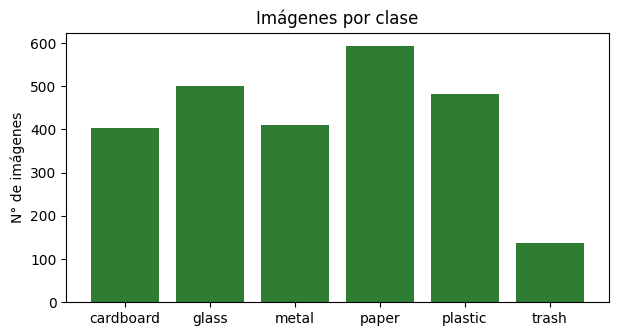

In [6]:
etiquetas = np.array(ds["label"])                         # etiqueta de cada imagen
conteo = np.bincount(etiquetas, minlength=len(NOMBRES))   # cuántas imágenes tiene cada clase

for n, c in zip(NOMBRES, conteo):
    print(f"{n:10s}: {c:5d}  ({c / conteo.sum():.1%})")
print("Razón mayor / menor clase:", round(conteo.max() / conteo.min(), 1))

plt.figure(figsize=(7, 3.5))
plt.bar(NOMBRES, conteo, color="#2e7d32")
plt.title("Imágenes por clase"); plt.ylabel("N° de imágenes"); plt.show()

### 1.2 Ejemplos de cada clase

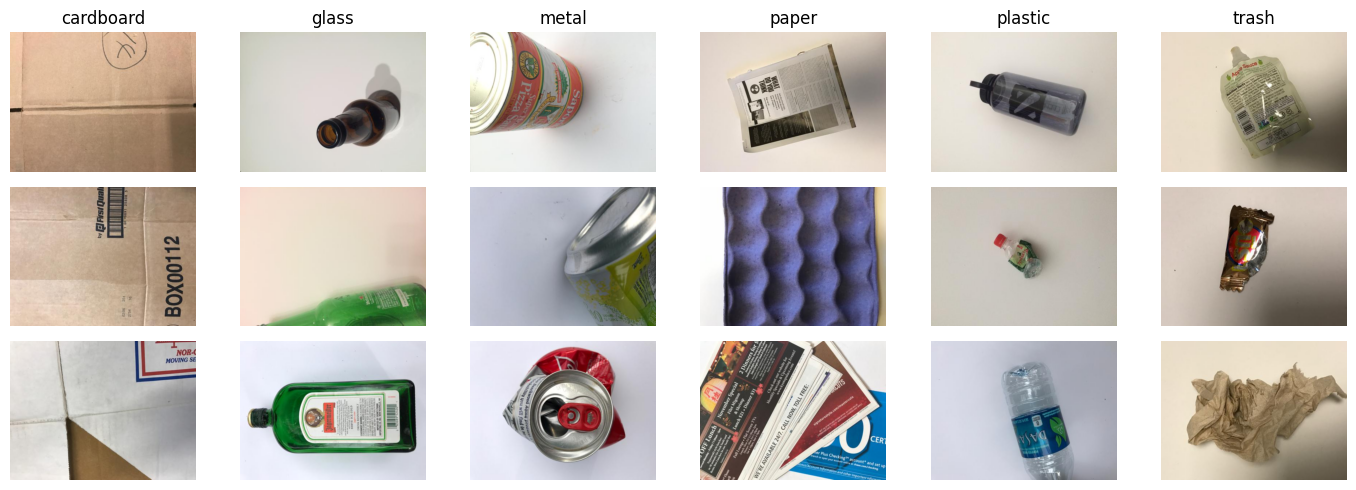

In [7]:
plt.figure(figsize=(14, 5))
for k, n in enumerate(NOMBRES):
    idx = np.where(etiquetas == k)[0][:3]                 # 3 fotos de la clase
    for j, i in enumerate(idx):
        plt.subplot(3, 6, j * 6 + k + 1)
        plt.imshow(ds[int(i)]["image"]); plt.axis("off")
        if j == 0: plt.title(n)
plt.tight_layout(); plt.show()

### 1.3 Duplicados exactos y división train / val / test
Si una misma foto cae en *train* y en *test*, el modelo "la recuerda" y la métrica sale inflada (**fuga de datos**). Verificamos que no haya copias exactas antes de dividir: se eliminaron 3, quedando 2.524 imágenes (1.766 train, 379 val y 379 test).


In [8]:
def huella(img):                                           # resumen único del contenido de la foto
    return hashlib.md5(img.convert("RGB").tobytes()).hexdigest()

vistos, unicos = set(), []
for i in range(len(ds)):
    h = huella(ds[i]["image"])
    if h not in vistos:                                    # solo conserva la primera copia
        vistos.add(h); unicos.append(i)
unicos = np.array(unicos)
print(f"Imágenes: {len(ds)} · duplicados exactos eliminados: {len(ds) - len(unicos)} · quedan: {len(unicos)}")

Imágenes: 2527 · duplicados exactos eliminados: 3 · quedan: 2524


In [9]:
y = etiquetas[unicos]                                      # etiquetas de las imágenes únicas
# 70 % train · 15 % val · 15 % test, manteniendo la proporción de cada clase (estratificado)
idx_train, idx_resto = train_test_split(unicos, test_size=0.30, stratify=y, random_state=SEMILLA)
idx_val, idx_test = train_test_split(idx_resto, test_size=0.50, stratify=etiquetas[idx_resto], random_state=SEMILLA)

print(f"{'clase':10s} {'train':>6s} {'val':>6s} {'test':>6s}")
for k, n in enumerate(NOMBRES):
    print(f"{n:10s} {(etiquetas[idx_train]==k).sum():6d} {(etiquetas[idx_val]==k).sum():6d} {(etiquetas[idx_test]==k).sum():6d}")
print(f"{'TOTAL':10s} {len(idx_train):6d} {len(idx_val):6d} {len(idx_test):6d}")

clase       train    val   test
cardboard     282     61     60
glass         350     75     76
metal         286     62     61
paper         416     89     89
plastic       336     72     72
trash          96     20     21
TOTAL        1766    379    379


**✏️ Limitaciones de los datos (para la ficha y la exposición):**
- **Una sola fuente y un entorno controlado:** fotos con fondo liso; en la vida real habrá fondos complejos, objetos sucios, aplastados o varios a la vez.
- **Desbalance:** la clase `trash` tiene solo 137 imágenes (5,4 %) frente a 594 de `paper`.
- **Muy pocas imágenes de `trash` en test:** solo 21, por lo que su recall (71,4 %) tiene mucha incertidumbre: una sola foto cambia el valor en casi 5 puntos.
- **Posibles casi-duplicados:** solo eliminamos 3 copias exactas; fotos casi iguales del mismo objeto podrían seguir repartidas entre train y test.
- **Sin diversidad geográfica:** los envases corresponden a productos de EE. UU., distintos a los chilenos.


## 2. Preparar los datos para PyTorch
Cada foto se redimensiona a 224×224 y se normaliza con las estadísticas de ImageNet (los modelos preentrenados lo esperan así). En *train* agregamos **aumento de datos** (voltear, rotar, variar color).

In [10]:
MEDIA, DESV = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]   # estadísticas de ImageNet
TAM = 224

tf_train = transforms.Compose([
    transforms.RandomResizedCrop(TAM, scale=(0.7, 1.0)),      # recorte aleatorio
    transforms.RandomHorizontalFlip(),                        # volteo horizontal
    transforms.RandomRotation(15),                            # rotación leve
    transforms.ColorJitter(0.2, 0.2, 0.2),                    # brillo, contraste, saturación
    transforms.ToTensor(), transforms.Normalize(MEDIA, DESV)])
tf_eval = transforms.Compose([                                # sin azar en val ni test
    transforms.Resize((TAM, TAM)),
    transforms.ToTensor(), transforms.Normalize(MEDIA, DESV)])

class Residuos(Dataset):
    def __init__(self, indices, tf):
        self.indices, self.tf = indices, tf
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, k):
        fila = ds[int(self.indices[k])]
        return self.tf(fila["image"].convert("RGB")), fila["label"]

LOTE = 32
dl_train = DataLoader(Residuos(idx_train, tf_train), batch_size=LOTE, shuffle=True, num_workers=2)
dl_val = DataLoader(Residuos(idx_val, tf_eval), batch_size=LOTE, num_workers=2)
dl_test = DataLoader(Residuos(idx_test, tf_eval), batch_size=LOTE, num_workers=2)

## 3. Evaluación común
Para comparar en igualdad de condiciones, **todos los modelos se miden con las mismas imágenes de prueba y con la misma métrica**: *accuracy* y *accuracy balanceada* (promedio del acierto de cada clase; al azar ≈ 17 %). La balanceada importa porque `trash` es una clase escasa.

In [11]:
y_test = etiquetas[idx_test]                                  # etiquetas reales del test

def evaluar(pred, nombre):
    acc = accuracy_score(y_test, pred)
    bal = balanced_accuracy_score(y_test, pred)
    print(f"{nombre}: accuracy = {acc:.3f} · accuracy balanceada = {bal:.3f}")
    return acc, bal

## 4. Línea base · CLIP sin entrenar (zero-shot)
CLIP compara la imagen con una frase por cada clase y elige la más parecida. **No usa ninguna de nuestras etiquetas para aprender**: es el punto de referencia mínimo.

In [12]:
from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DISPOSITIVO).eval()
proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

frases = ["a photo of cardboard waste", "a photo of glass waste", "a photo of metal waste",
          "a photo of paper waste", "a photo of plastic waste", "a photo of general trash"]
assert [n for n in NOMBRES] == ["cardboard", "glass", "metal", "paper", "plastic", "trash"], NOMBRES

pred_clip = []
with torch.no_grad():
    for i in range(0, len(idx_test), 32):
        fotos = [ds[int(j)]["image"].convert("RGB") for j in idx_test[i:i + 32]]
        entrada = proc(text=frases, images=fotos, return_tensors="pt", padding=True).to(DISPOSITIVO)
        pred_clip += clip(**entrada).logits_per_image.argmax(dim=1).cpu().tolist()
pred_clip = np.array(pred_clip)

acc_clip, bal_clip = evaluar(pred_clip, "CLIP zero-shot")
del clip; torch.cuda.empty_cache()

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP zero-shot: accuracy = 0.660 · accuracy balanceada = 0.599


## 5. Modelo principal · EfficientNet-B0 con *transfer learning* (timm)
Cargamos EfficientNet-B0 preentrenada en ImageNet, **cambiamos su salida a 6 clases** y la ajustamos con nuestras fotos con una tasa de aprendizaje pequeña (para no "olvidar" lo que ya sabe). Como `trash` es escasa, usamos una **pérdida ponderada por clase**.

In [13]:
modelo = timm.create_model("efficientnet_b0", pretrained=True, num_classes=len(NOMBRES)).to(DISPOSITIVO)

pesos = torch.tensor(len(idx_train) / (len(NOMBRES) * np.bincount(etiquetas[idx_train])), dtype=torch.float32)
print("Peso por clase:", dict(zip(NOMBRES, pesos.numpy().round(2))))      # más peso a la clase escasa

perdida = nn.CrossEntropyLoss(weight=pesos.to(DISPOSITIVO))
optim = torch.optim.AdamW(modelo.parameters(), lr=1e-4)                    # tasa de aprendizaje pequeña

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Peso por clase: {'cardboard': np.float32(1.04), 'glass': np.float32(0.84), 'metal': np.float32(1.03), 'paper': np.float32(0.71), 'plastic': np.float32(0.88), 'trash': np.float32(3.07)}


In [14]:
def predecir(dl):
    modelo.eval(); todas = []
    with torch.no_grad():
        for x, _ in dl:
            todas.append(torch.softmax(modelo(x.to(DISPOSITIVO)), dim=1).cpu())
    return torch.cat(todas).numpy()                                         # probabilidades por clase

EPOCAS, PACIENCIA = 8, 3
y_val = etiquetas[idx_val]
historia = {"loss": [], "val_bal": []}
mejor, sin_mejora = 0, 0

for ep in range(EPOCAS):
    modelo.train(); acumulada = 0
    for x, y_lote in dl_train:
        x, y_lote = x.to(DISPOSITIVO), y_lote.to(DISPOSITIVO)
        optim.zero_grad()
        l = perdida(modelo(x), y_lote)
        l.backward(); optim.step()
        acumulada += l.item() * len(x)
    val_bal = balanced_accuracy_score(y_val, predecir(dl_val).argmax(1))   # se mide en VALIDACIÓN, no en test
    historia["loss"].append(acumulada / len(idx_train)); historia["val_bal"].append(val_bal)
    print(f"Época {ep+1}/{EPOCAS} · pérdida train {historia['loss'][-1]:.3f} · accuracy balanceada val {val_bal:.3f}")
    if val_bal > mejor:                                                    # guarda el mejor modelo
        mejor, sin_mejora = val_bal, 0
        torch.save(modelo.state_dict(), "mejor.pt")
    else:
        sin_mejora += 1
        if sin_mejora >= PACIENCIA:
            print("Parada temprana: la validación dejó de mejorar."); break

modelo.load_state_dict(torch.load("mejor.pt"))                              # vuelve al mejor modelo

Época 1/8 · pérdida train 1.849 · accuracy balanceada val 0.642
Época 2/8 · pérdida train 0.656 · accuracy balanceada val 0.730
Época 3/8 · pérdida train 0.354 · accuracy balanceada val 0.770
Época 4/8 · pérdida train 0.281 · accuracy balanceada val 0.830
Época 5/8 · pérdida train 0.193 · accuracy balanceada val 0.827
Época 6/8 · pérdida train 0.148 · accuracy balanceada val 0.813
Época 7/8 · pérdida train 0.116 · accuracy balanceada val 0.833
Época 8/8 · pérdida train 0.077 · accuracy balanceada val 0.849


<All keys matched successfully>

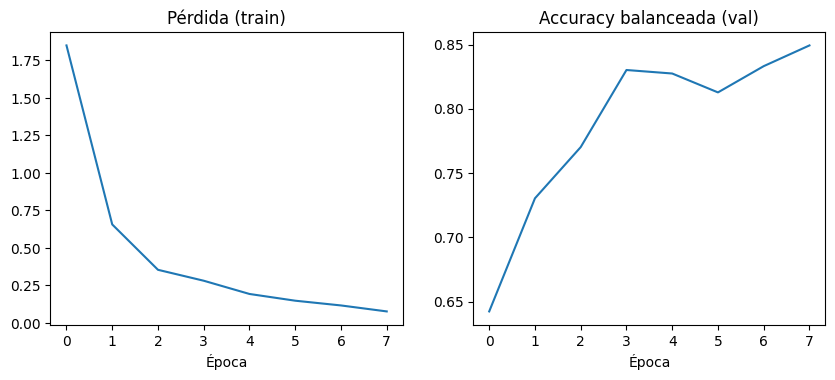

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(historia["loss"]); ax[0].set_title("Pérdida (train)"); ax[0].set_xlabel("Época")
ax[1].plot(historia["val_bal"]); ax[1].set_title("Accuracy balanceada (val)"); ax[1].set_xlabel("Época")
plt.show()

**✏️ ¿Hay overfitting?** Las 8 épocas se completaron sin que se activara la parada temprana. La pérdida de train baja de forma sostenida (de 1,85 a 0,08) y la accuracy balanceada de validación sube de 0,64 a 0,85. Hay una pequeña baja en las épocas 5 y 6 (de 0,83 a 0,81), pero se recupera y la curva sigue subiendo al final. No veo señales claras de overfitting. El valor de validación (0,85) es cercano al del test (0,83), lo que apoya que el modelo generaliza. Como la validación seguía mejorando, con más épocas podría subir un poco más.


## 6. Resultados en el conjunto de **prueba**
Esta es la primera vez que el modelo ve el *test*. Estas cifras son el desempeño real que mostrará la app (distinto de la confianza de cada imagen).

In [16]:
prob_test = predecir(dl_test)
pred_eff = prob_test.argmax(1)

acc_eff, bal_eff = evaluar(pred_eff, "EfficientNet-B0")
acc_clip, bal_clip = evaluar(pred_clip, "CLIP zero-shot (línea base)")
print()
print(classification_report(y_test, pred_eff, target_names=NOMBRES, digits=3))

EfficientNet-B0: accuracy = 0.836 · accuracy balanceada = 0.826
CLIP zero-shot (línea base): accuracy = 0.660 · accuracy balanceada = 0.599

              precision    recall  f1-score   support

   cardboard      0.952     0.983     0.967        60
       glass      0.785     0.961     0.864        76
       metal      0.870     0.770     0.817        61
       paper      0.958     0.775     0.857        89
     plastic      0.885     0.750     0.812        72
       trash      0.405     0.714     0.517        21

    accuracy                          0.836       379
   macro avg      0.809     0.826     0.806       379
weighted avg      0.864     0.836     0.842       379



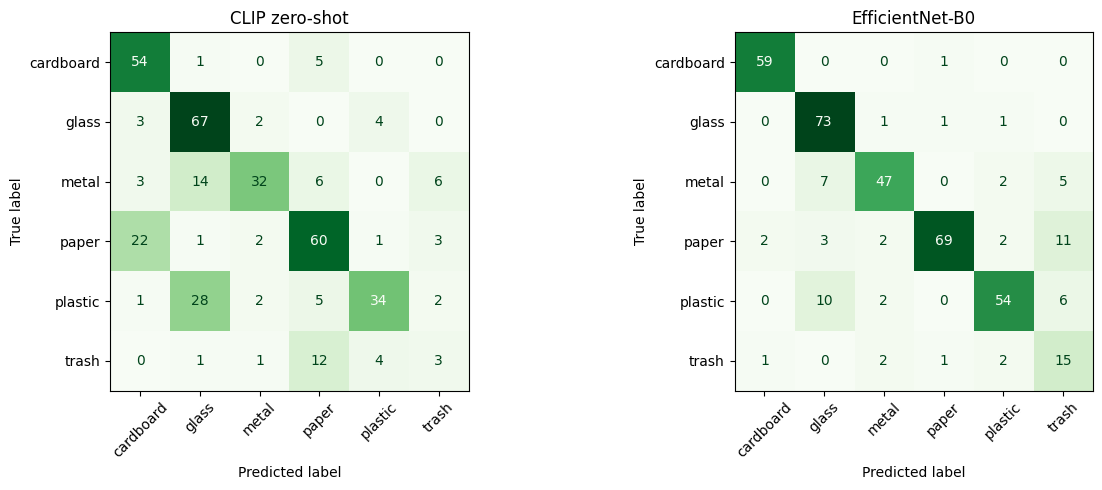

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, pred, titulo in [(ax[0], pred_clip, "CLIP zero-shot"), (ax[1], pred_eff, "EfficientNet-B0")]:
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=NOMBRES).plot(ax=a, cmap="Greens", colorbar=False)
    a.set_title(titulo); a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

**✏️ Justificación de la elección.** EfficientNet-B0 supera a CLIP sin entrenar en las mismas 379 imágenes de prueba: 83,6 % contra 66,0 % de accuracy, y 82,6 % contra 59,9 % de accuracy balanceada. CLIP no usa nuestras etiquetas y confunde clases parecidas (por ejemplo, 28 plásticos como vidrio); el transfer learning se adapta a los residuos. Además EfficientNet-B0 pesa unos 16 MB, cabe en GitHub y corre en CPU en Streamlit Cloud.

**✏️ Error más costoso.** El más grave es que un residuo no reciclable quede como reciclable, porque contamina el lote completo: ocurrió con 6 de 21 imágenes trash (28,6 %), con un recall de trash de 71,4 %. El error inverso también cuesta, porque se pierde material reciclable: 22 imágenes reciclables se clasificaron como trash (11 papel, 6 plástico y 5 metal). La pérdida ponderada por clase mejora el recall de trash, pero baja su precision (0,41).


In [18]:
cm = confusion_matrix(y_test, pred_eff)
k_trash = NOMBRES.index("trash")
fuga = cm[k_trash].sum() - cm[k_trash, k_trash]
print(f"'trash' clasificada como material reciclable: {fuga} de {cm[k_trash].sum()} ({fuga / cm[k_trash].sum():.1%})")
print(f"Recall de trash: {cm[k_trash, k_trash] / cm[k_trash].sum():.1%}")

'trash' clasificada como material reciclable: 6 de 21 (28.6%)
Recall de trash: 71.4%


### 6.1 ¿Cuándo desconfiar? Confianza de las predicciones

In [19]:
confianza = prob_test.max(1)
correcto = pred_eff == y_test
print(f"Confianza media cuando acierta: {confianza[correcto].mean():.2f} · cuando se equivoca: {confianza[~correcto].mean():.2f}")
for umbral in (0.5, 0.6, 0.7, 0.8, 0.9):
    m = confianza >= umbral
    print(f"Confianza ≥ {umbral:.1f}: {m.mean():.0%} de las fotos · accuracy en ese grupo = {correcto[m].mean():.3f}")

Confianza media cuando acierta: 0.95 · cuando se equivoca: 0.74
Confianza ≥ 0.5: 97% de las fotos · accuracy en ese grupo = 0.856
Confianza ≥ 0.6: 93% de las fotos · accuracy en ese grupo = 0.878
Confianza ≥ 0.7: 89% de las fotos · accuracy en ese grupo = 0.890
Confianza ≥ 0.8: 84% de las fotos · accuracy en ese grupo = 0.906
Confianza ≥ 0.9: 76% de las fotos · accuracy en ese grupo = 0.934


La confianza media es 0,95 cuando el modelo acierta y 0,74 cuando se equivoca, así que sirve para detectar casos dudosos. Con confianza ≥ 0,7 pasa el 89 % de las fotos con 89,0 % de accuracy; el 11 % restante se deriva a revisión humana. Por eso la app usa `UMBRAL_CONFIANZA = 0.70`.


### 6.2 ¿Dónde se equivocó?

Errores: 62 de 379


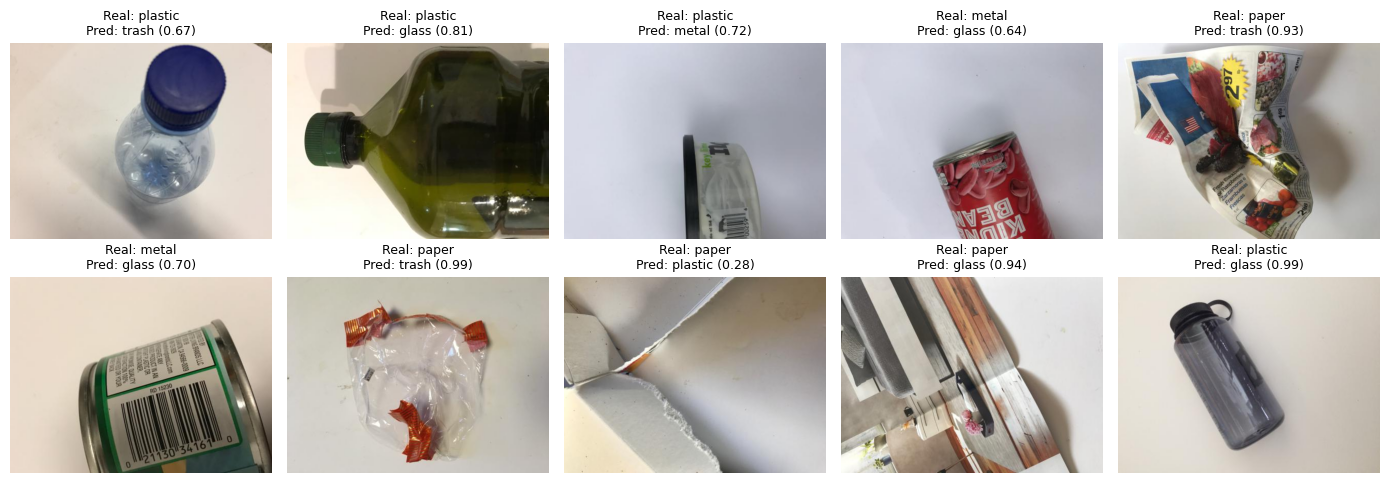

In [20]:
errores = np.where(~correcto)[0]
print("Errores:", len(errores), "de", len(y_test))
plt.figure(figsize=(14, 5))
for k, e in enumerate(errores[:10]):
    plt.subplot(2, 5, k + 1)
    plt.imshow(ds[int(idx_test[e])]["image"]); plt.axis("off")
    plt.title(f"Real: {NOMBRES[y_test[e]]}\nPred: {NOMBRES[pred_eff[e]]} ({confianza[e]:.2f})", fontsize=9)
plt.tight_layout(); plt.show()

## 7. Exportar para la app
Se guardan tres archivos en la carpeta `modelo/` del repositorio: los **pesos**, los **nombres de las clases** y las **métricas del test** (la app las muestra como desempeño del modelo).

In [21]:
os.makedirs("modelo", exist_ok=True)
torch.save(modelo.state_dict(), "modelo/modelo_efficientnet.pt")
json.dump(NOMBRES, open("modelo/clases.json", "w"), ensure_ascii=False)

recall = {n: float(cm[k, k] / cm[k].sum()) for k, n in enumerate(NOMBRES)}
json.dump({
    "accuracy": acc_eff, "accuracy_balanceada": bal_eff, "n_test": int(len(y_test)),
    "recall_por_clase": recall, "clip_accuracy": acc_clip, "clip_accuracy_balanceada": bal_clip,
}, open("modelo/metricas.json", "w"), ensure_ascii=False, indent=2)

print("Tamaño de los pesos:", round(os.path.getsize("modelo/modelo_efficientnet.pt") / 1e6, 1), "MB (GitHub acepta hasta 100 MB)")

Tamaño de los pesos: 16.4 MB (GitHub acepta hasta 100 MB)


In [22]:
# guarda 5 imágenes de prueba (una por clase, más una de 'trash') para la carpeta ejemplos/ del repositorio
os.makedirs("ejemplos", exist_ok=True)
for k, n in enumerate(NOMBRES):
    i = int(idx_test[np.where(y_test == k)[0][0]])
    ds[i]["image"].convert("RGB").resize((384, 384)).save(f"ejemplos/{n}.jpg")

# descarga todo en un zip para subirlo a GitHub
!zip -qr entrega_modelo.zip modelo ejemplos
from google.colab import files
files.download("entrega_modelo.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Conclusiones

- **Modelo:** EfficientNet-B0 con transfer learning alcanzó 83,6 % de accuracy y 82,6 % de accuracy balanceada en test, contra 66,0 % y 59,9 % de CLIP sin entrenar. Ganó por 17,6 y 22,7 puntos.
- **Clases:** cardboard y glass se reconocen muy bien (recall 0,98 y 0,96). Paper, metal, plastic y trash están entre 0,71 y 0,78. La más difícil es trash (precision 0,41), por ser solo el 5,4 % de los datos.
- **Error más costoso:** que trash pase por reciclable (6 de 21) contamina el lote. También se pierde material al mandar reciclables a trash (22 casos).
- **Confianza:** bajo 0,7 la app pide revisión humana; sobre ese valor la accuracy sube a 89,0 %.
- **Limitaciones:** una sola fuente con fondos simples, envases de EE. UU., solo 21 imágenes trash en test y posibles casi-duplicados.
- **Mejoras futuras:** agregar fotos propias con fondos reales y envases chilenos, más imágenes de trash, ajustar el peso de las clases y probar más épocas o un modelo más grande.

> ⚠️ Prototipo educativo: no reemplaza las indicaciones de la municipalidad ni de un punto limpio.
